# Ray collisions: what an observer sees

`RayTracer.ray_collisions(x, y, dx, dy, observer_altitude, min_elevation, max_elevation, resolution)` (`rust/src/ray_collisions.rs`) casts `resolution` rays in one horizontal direction, at elevation angles evenly spaced from `min_elevation` to `max_elevation` (radians, both included). For each angle it returns the distance the ray travels before hitting the surface, `inf` if it probably reaches the sky, or `-inf` if it probably reaches the ocean (the dataset has no points over open water).

It walks the horizontal ray (`cast_ray`) once. A ray passing above a point also passes above it at every higher angle, so each angle resumes the search where the previous one stopped. Earth curvature (with standard refraction) is included.

Doing this for every bearing gives a panorama: **columns = directions, rows = elevation angles**, each pixel = distance to the first surface hit.

Run with the **viewfinder-backend** kernel.

In [1]:
import math
import pathlib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from viewfinder_core import RayTracer

u16_path = pathlib.Path("~/data/lidar-vancouver-u16").expanduser()
rt = RayTracer(u16_path)
index = pd.read_csv(u16_path / "index.csv")
EYE_HEIGHT = 2.0  # metres above the surface the observer stands on


def latlon_to_utm(lat, lon):
    """UTM (EPSG:26910) from lat/lon using the parcel corner coordinates in index.csv."""
    t = index[(index.lat_sw <= lat) & (index.lat_nw >= lat) & (index.lon_nw <= lon) & (index.lon_ne >= lon)].iloc[0]
    u = (lon - t.lon_nw) / (t.lon_ne - t.lon_nw)
    v = (t.lat_nw - lat) / (t.lat_nw - t.lat_sw)
    return t.x_start + u * (t.x_end - t.x_start), t.y_start + v * (t.y_end - t.y_start)


def highest_spot(x, y, radius=15.0):
    """(altitude, x, y) of the top of the roof or summit near (x, y): climbs until no point within
    `radius` m is higher, so the observer is not standing next to a taller part of the same building."""
    offsets = np.arange(-radius, radius + 0.1, rt.cell_size)
    best = (rt.altitude_at(x, y), x, y)
    while True:
        candidates = [(rt.altitude_at(best[1] + dx, best[2] + dy), best[1] + dx, best[2] + dy) for dx in offsets for dy in offsets]
        top = max(c for c in candidates if c[0] is not None)
        if top[0] <= best[0]:
            return best
        best = top


def direction(bearing):
    """Unit vector for a bearing in degrees clockwise from north."""
    return math.sin(math.radians(bearing)), math.cos(math.radians(bearing))

## One direction

From the top of Harbour Centre (downtown), looking west over Coal Harbour and Stanley Park. The grey area is the terrain under the ray (with Earth curvature applied, as the algorithm sees it). Each line is one elevation angle and ends where `ray_collisions` says it hits the surface.

In [2]:
harbour_altitude, hx, hy = highest_spot(*latlon_to_utm(49.28483, -123.11188))
observer_altitude = harbour_altitude + EYE_HEIGHT
bearing = 285
angles_deg = np.linspace(-6, 3, 10)

distances = rt.ray_collisions(hx, hy, *direction(bearing), observer_altitude,
                              math.radians(angles_deg[0]), math.radians(angles_deg[-1]), len(angles_deg))
pd.DataFrame({"elevation (deg)": angles_deg.round(1), "result": distances})

,elevation (deg),result
0,-6.0,433.435014
1,-5.0,432.707193
2,-4.0,472.068680
3,-3.0,679.422744
4,-2.0,874.691655
5,-1.0,874.291976
6,0.0,874.158817
7,1.0,874.291976
8,2.0,inf
9,3.0,inf


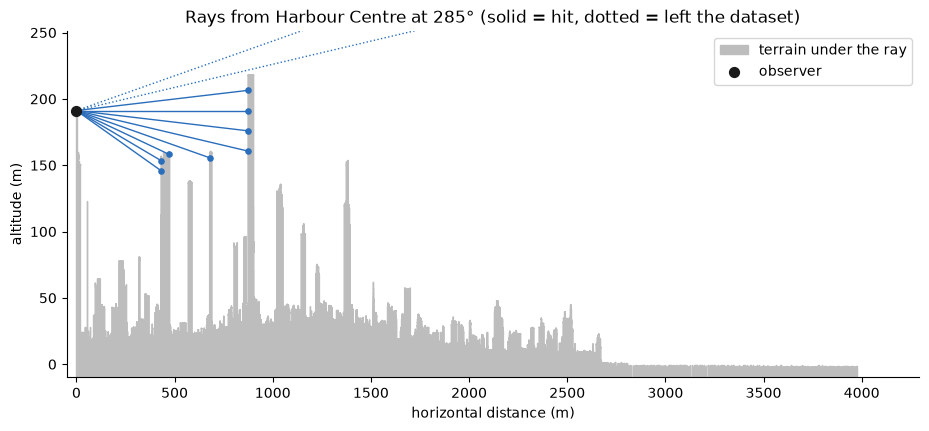

In [3]:
profile = pd.DataFrame(rt.cast_ray(hx, hy, *direction(bearing)), columns=["x", "y", "altitude"])
profile["altitude"] = profile["altitude"].astype(float)
profile["distance"] = np.hypot(profile.x - hx, profile.y - hy)
EARTH_RADIUS, REFRACTION = 6_371_000.0, 0.13
profile["apparent"] = profile.altitude - profile.distance ** 2 * (1 - REFRACTION) / (2 * EARTH_RADIUS)
end = profile.distance.max()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(profile.distance, profile.apparent, -10, color="#bdbdbd", step="mid", label="terrain under the ray")
for angle, result in zip(angles_deg, distances):
    slope = math.tan(math.radians(angle))
    if math.isfinite(result):
        horizontal = result * math.cos(math.radians(angle))
        ax.plot([0, horizontal], [observer_altitude, observer_altitude + horizontal * slope], color="#2a6ebb", lw=1)
        ax.scatter(horizontal, observer_altitude + horizontal * slope, s=14, color="#2a6ebb", zorder=3)
    else:
        ax.plot([0, end], [observer_altitude, observer_altitude + end * slope], color="#2a6ebb", lw=1, ls=":")
        ax.annotate("sky" if result > 0 else "ocean", (end, observer_altitude + end * slope), xytext=(4, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#555555")
ax.scatter(0, observer_altitude, s=50, color="#1a1a1a", zorder=4, label="observer")
ax.set_xlim(-50, end * 1.08)
ax.set_ylim(-10, observer_altitude + 60)
ax.set_title(f"Rays from Harbour Centre at {bearing}° (solid = hit, dotted = left the dataset)")
ax.set_xlabel("horizontal distance (m)")
ax.set_ylabel("altitude (m)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right")
plt.show()

## Panoramas

Columns are bearings (0° = north, clockwise) and rows are elevation angles, highest at the top. The colour is the distance to the first surface hit on a log scale: dark = near, light = far.

In [4]:
SKY, OCEAN = "#a6cbea", "#1f4e8c"
distance_cmap = plt.get_cmap("Greys_r").with_extremes(over=SKY, under=OCEAN)


def panorama(x, y, altitude, n_bearings=1440, min_elevation=-8.0, max_elevation=12.0, n_elevations=400):
    """Distances for every (elevation, bearing); rows top = highest elevation. inf = sky, -inf = ocean."""
    bearings = np.arange(n_bearings) * 360 / n_bearings
    columns = [rt.ray_collisions(x, y, *direction(b), altitude, math.radians(min_elevation), math.radians(max_elevation), n_elevations)
               for b in bearings]
    return np.array(columns).T[::-1], (0, 360, min_elevation, max_elevation)


def show_panorama(image, extent, title):
    # Sky/ocean become values just outside the colour range so the colormap paints them with its over/under colours
    vmin, vmax = 1.0, 10_000.0
    shown = np.where(np.isposinf(image), vmax * 10, np.where(np.isneginf(image), vmin / 10, np.clip(image, vmin, vmax)))
    fig, ax = plt.subplots(figsize=(14, 4.2))
    im = ax.imshow(shown, cmap=distance_cmap, norm=LogNorm(vmin, vmax), extent=extent, aspect="auto", interpolation="nearest")
    ax.axhline(0, color="#e8710a", lw=0.8, ls="--")
    ax.set_xticks(range(0, 361, 45), ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"])
    ax.set_xlabel("direction")
    ax.set_ylabel("elevation angle (°)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="distance to first hit (m)", pad=0.01)
    ax.legend(handles=[Patch(color=SKY, label="probably sky"), Patch(color=OCEAN, label="probably ocean"),
                       plt.Line2D([], [], color="#e8710a", lw=0.8, ls="--", label="horizontal")],
              loc="upper left", fontsize=8, framealpha=0.9)
    plt.show()


def summary(image):
    hits = image[np.isfinite(image)]
    return pd.Series({
        "rays": f"{image.size:,}",
        "hit the surface": f"{hits.size / image.size:.0%}",
        "probably sky": f"{np.isposinf(image).mean():.0%}",
        "probably ocean": f"{np.isneginf(image).mean():.0%}",
        "median hit distance (m)": round(float(np.median(hits))),
        "farthest hit (m)": round(float(hits.max())),
    }, name="value").to_frame()

576,000 rays in 1.2 s, observer at 191.2 m


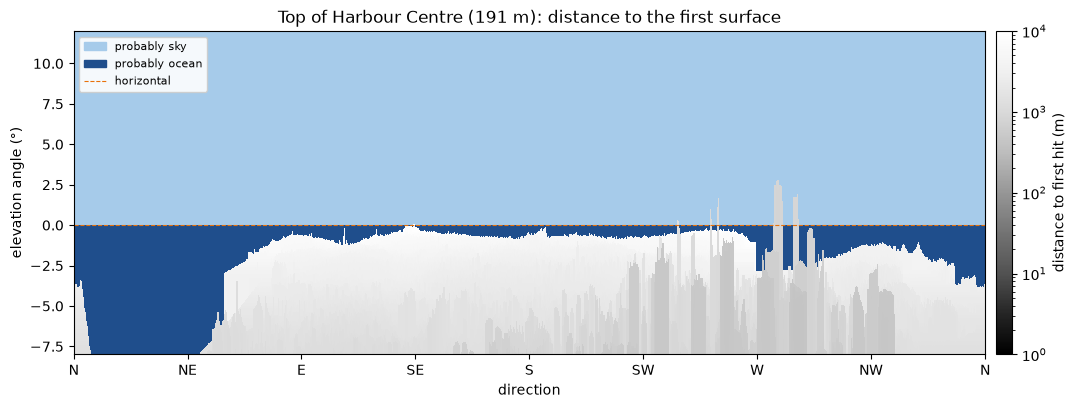

,value
rays,"576,000"
hit the surface,30%
probably sky,60%
probably ocean,11%
median hit distance (m),1668
farthest hit (m),10785


In [5]:
start = time.perf_counter()
image, extent = panorama(hx, hy, observer_altitude)
print(f"{image.size:,} rays in {time.perf_counter() - start:.1f} s, observer at {observer_altitude:.1f} m")
show_panorama(image, extent, f"Top of Harbour Centre ({observer_altitude:.0f} m): distance to the first surface")
summary(image)

576,000 rays in 1.4 s, observer at 142.4 m


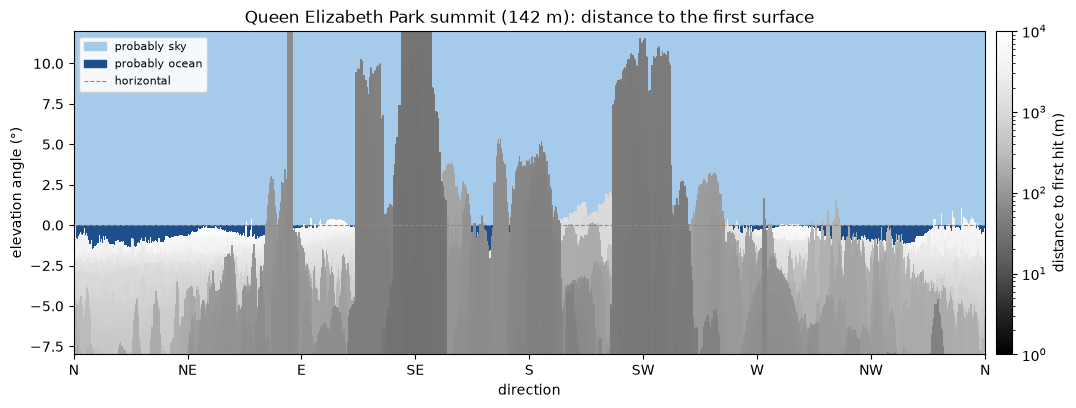

,value
rays,"576,000"
hit the surface,50%
probably sky,49%
probably ocean,1%
median hit distance (m),81
farthest hit (m),10466


In [6]:
qe_altitude, qx, qy = highest_spot(*latlon_to_utm(49.2418, -123.1126))
start = time.perf_counter()
image, extent = panorama(qx, qy, qe_altitude + EYE_HEIGHT)
print(f"{image.size:,} rays in {time.perf_counter() - start:.1f} s, observer at {qe_altitude + EYE_HEIGHT:.1f} m")
show_panorama(image, extent, f"Queen Elizabeth Park summit ({qe_altitude + EYE_HEIGHT:.0f} m): distance to the first surface")
summary(image)

## Reading the panoramas

- **Sky vs ocean is a guess based on the ray's direction.** A ray that leaves the dataset without hitting anything is called sky if it points up and ocean if it points down. There are no points over open water, so looking down at Burrard Inlet or English Bay gives "ocean". But land beyond the edge of the dataset gives "ocean" too, for example the North Shore seen from QE Park.
- **The surface is the highest LiDAR return per 0.5 m cell,** so trees, masts and roofs all block rays. The observer stands on the highest surface near the chosen point, which is the mast top at Harbour Centre and the canopy at QE Park, and the nearby trees fill much of the QE view.
- **Earth curvature is why distant land sits slightly below 0°.** Even land at the observer's own altitude appears below the horizontal line once it is a few km away.